In [36]:
import os
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import warnings
from collections import Counter
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

In [37]:
def center_in_45(image):
    h, w = image.shape
    squared = np.zeros((45, 45), dtype=np.uint8)
    y_offset = (45 - h) // 2
    x_offset = (45 - w) // 2
    squared[y_offset:y_offset+h, x_offset:x_offset+w] = image
    return squared
def predict_symbol(model, image):
    image = cv2.bitwise_not(image)  # Инверсия только здесь!
    img_centered = center_in_45(image)
    img_flat = img_centered.flatten()
    return model.predict([img_flat])[0]

In [42]:
def load_and_split_data(data_path='./data', symbols=None, train_size=0.8, max_per_class=2000):
    if symbols is None:
        all_folders = [d for d in os.listdir(data_path) 
                       if os.path.isdir(os.path.join(data_path, d)) and not d.startswith('.')]
        symbols = all_folders
    X_train, y_train = [], []
    X_test, y_test = [], []
    print(f"Обучение: {train_size*100}%, Тест: {(1-train_size)*100}%")
    print(f"Максимум {max_per_class} файлов на класс")
    for symbol in symbols:
        symbol_path = os.path.join(data_path, symbol)
        try:
            all_files = [f for f in os.listdir(symbol_path) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        except:
            continue
        if not all_files:
            continue
        all_files.sort()
        if len(all_files) > max_per_class:
            all_files = all_files[:max_per_class]
        split_idx = int(len(all_files) * train_size)
        train_files = all_files[:split_idx]
        test_files = all_files[split_idx:]
        print(f"{symbol}: обучение={len(train_files)}, тест={len(test_files)}")
        for img_file in train_files:
            img_path = os.path.join(symbol_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                X_train.append(img.flatten())
                y_train.append(symbol)
        for img_file in test_files:
            img_path = os.path.join(symbol_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                X_test.append(img.flatten())
                y_test.append(symbol)
    print(f"Итого:")
    print(f"Обучающая выборка: {len(X_train)} изображений")
    print(f"Тестовая выборка: {len(X_test)} изображений")
    print(f"Всего: {len(X_train) + len(X_test)} изображений")
    print(f"Классов: {len(np.unique(y_train))}")
    return (np.array(X_train), np.array(y_train), 
            np.array(X_test), np.array(y_test), symbols)
print("1. Загрузка и разделение данных")
symbols_list = ['0','1','2','3','4','5','6','7','8','9','+','-','times','t','X','y','w','h','(',')',',']
X_train, y_train, X_test, y_test, symbols = load_and_split_data(
    './data', 
    symbols=symbols_list,
    train_size=0.8,
    max_per_class=2000  # 2000 на класс = 1600 обучение + 400 тест
)

1. Загрузка и разделение данных
Обучение: 80.0%, Тест: 19.999999999999996%
Максимум 2000 файлов на класс
0: обучение=1600, тест=400
1: обучение=1600, тест=400
2: обучение=1600, тест=400
3: обучение=1600, тест=400
4: обучение=1600, тест=400
5: обучение=1600, тест=400
6: обучение=1600, тест=400
7: обучение=1600, тест=400
8: обучение=1600, тест=400
9: обучение=502, тест=126
+: обучение=1600, тест=400
-: обучение=1600, тест=400
times: обучение=1600, тест=400
t: обучение=1600, тест=400
X: обучение=1600, тест=400
y: обучение=1600, тест=400
w: обучение=444, тест=112
h: обучение=1171, тест=293
(: обучение=1600, тест=400
): обучение=1600, тест=400
,: обучение=1524, тест=382
Итого:
Обучающая выборка: 30841 изображений
Тестовая выборка: 7713 изображений
Всего: 38554 изображений
Классов: 21


In [43]:
print("2. Обучение моделей KNN")
knn1 = KNeighborsClassifier(n_neighbors=1)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
knn7 = KNeighborsClassifier(n_neighbors=7)
knn1.fit(X_train, y_train)
knn3.fit(X_train, y_train)
knn5.fit(X_train, y_train)
knn7.fit(X_train, y_train)
models = {
    'knn1': knn1,
    'knn3': knn3,
    'knn5': knn5,
    'knn7': knn7
}

2. Обучение моделей KNN


In [44]:
print("3. Оценка моделей на тестовой выборке.")
print(f"Оценка на {len(X_test)} тестовых примерах.")
test_results = {}
for name, model in models.items():
    print(f"\n{name}:")
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    accuracy = accuracy_score(y_test, y_pred)
    test_results[name] = {
        'accuracy': accuracy,
        'time': pred_time,
        'y_pred': y_pred
    }
    print(f"  Точность: {accuracy:.4f}")
    print(f"  Время: {pred_time:.1f} сек")

best_model_name = max(test_results, key=lambda x: test_results[x]['accuracy'])
best_accuracy = test_results[best_model_name]['accuracy']
print(f"Лучшая модель: {best_model_name}")
print(f"Точность: {best_accuracy:.4f}")

3. Оценка моделей на тестовой выборке.
Оценка на 7713 тестовых примерах.

knn1:
  Точность: 0.7285
  Время: 8.1 сек

knn3:
  Точность: 0.4942
  Время: 8.1 сек

knn5:
  Точность: 0.4173
  Время: 8.1 сек

knn7:
  Точность: 0.3762
  Время: 8.1 сек
Лучшая модель: knn1
Точность: 0.7285


In [45]:
print("4. Создание генератора последовательностей.")
class SymbolGenerator:
    def __init__(self, data_path):
        self.data_path = data_path
        self.available_symbols = list(('(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*'))
        print("Доступные символы:", self.available_symbols) 
    def get_random_symbol_image(self, char):
        folder_name = char
        if char == 'x':
            folder_name = 'X'
        if char == '*':
            folder_name = 'times'
        symbol_dir = os.path.join(self.data_path, folder_name)
        images = [f for f in os.listdir(symbol_dir) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        images.sort()  
        start_index = int(len(images) * 0.8)
        last_20_percent = images[start_index:]
        if not last_20_percent:
            return None
        random_image = random.choice(last_20_percent)
        img_path = os.path.join(symbol_dir, random_image)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)    
        return img
    def generate_sequence(self, length=6):
        sequence = ''.join(random.choices(self.available_symbols, k=length))
        print(f"Генерируется: {sequence}")
        images = []
        for char in sequence:
            img = self.get_random_symbol_image(char)
            if img is not None:
                images.append(img)
        return sequence, images
generator = SymbolGenerator('./data')

4. Создание генератора последовательностей.
Доступные символы: ['(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*']



Генерация тестовой последовательности.
Генерируется: 7y4)t8


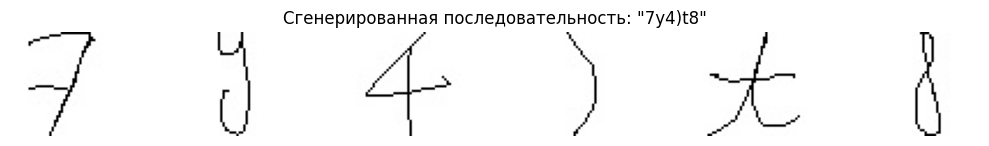

In [51]:
def create_sequence_image(images, spacing=30):
    total_width = sum(img.shape[1] for img in images) + spacing * (len(images) - 1)
    max_height = max(img.shape[0] for img in images)
    sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255
    x_offset = 0
    for img in images:
        h, w = img.shape
        y_offset = (max_height - h) 
        sequence_img[y_offset:y_offset+h, x_offset:x_offset+w] = img
        x_offset += w + spacing
    return sequence_img
print("\nГенерация тестовой последовательности.")
sequence, images = generator.generate_sequence(length=6)
sequence_image = create_sequence_image(images, spacing=30)
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.imshow(sequence_image, cmap='gray')
ax.set_title(f'Сгенерированная последовательность: "{sequence}"')
ax.axis('off')
plt.tight_layout()
plt.show()

5. Сегментация последовательности
Обрабатывается последовательность: '7y4)t8'


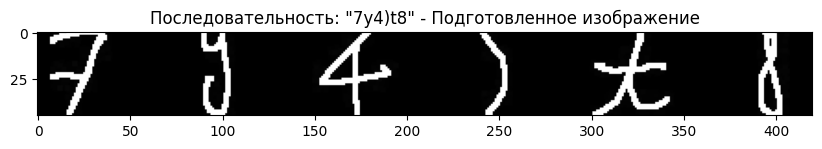

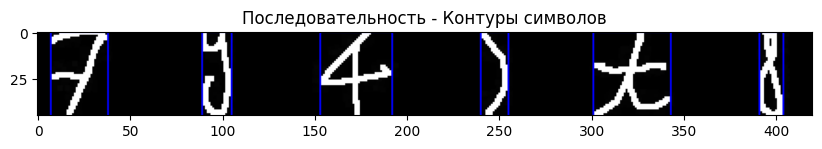


Извлечено 6 символов:


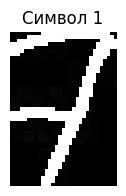

  Символ 1: размер (45, 31)


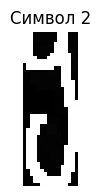

  Символ 2: размер (45, 16)


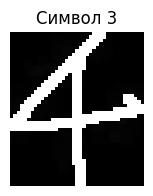

  Символ 3: размер (45, 39)


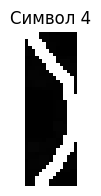

  Символ 4: размер (45, 15)


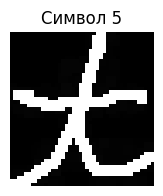

  Символ 5: размер (45, 42)


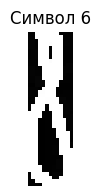

  Символ 6: размер (45, 13)


In [52]:
print("5. Сегментация последовательности")
print(f"Обрабатывается последовательность: '{sequence}'")
img_gray = sequence_image.copy()
kernel = np.ones((3,3), np.uint8)
img_gray = cv2.erode(img_gray, kernel, iterations=1)
img_gray = cv2.bitwise_not(img_gray)
base_size = img_gray.shape[0], img_gray.shape[1]
base = np.zeros(base_size, dtype=np.uint8)
base[0:img_gray.shape[0], 0:img_gray.shape[1]] = img_gray
base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)
img_rgb = base

plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Последовательность: "{sequence}" - Подготовленное изображение')
plt.show()

ret, thresh = cv2.threshold(img_rgb, 127, 255, 0)
thresh = np.uint8(thresh)
contours, h = cv2.findContours(thresh[:,:,0], cv2.RETR_EXTERNAL, 2)
crops = []
contours_sorted = sorted(contours, key=lambda cnt: cv2.boundingRect(cnt)[0])
for i in range(len(contours_sorted)):
    cnt = contours_sorted[i] 
    x, y, w, h = cv2.boundingRect(cnt)
    while (w > 45):
        w -= 1
    if w * h > 50:
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 0, 255), 1)
        crops.append([x, y, w, h])
plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Последовательность - Контуры символов')
plt.show()
sequence_symbols = []
print(f"\nИзвлечено {len(crops)} символов:")
for i in range(len(crops)):
    x, y, w, h = crops[i]
    img_crop = img_gray[y:y+h, x:x+w]
    base_img = img_crop.copy()
    plt.figure(figsize=(2, 2))
    plt.imshow(base_img, cmap="gray")
    plt.title(f'Символ {i+1}')
    plt.axis('off')
    plt.show()
    sequence_symbols.append((x, base_img))
    print(f"  Символ {i+1}: размер {img_crop.shape}")
resized_symbols = []
for x, symbol_img in sequence_symbols:
    resized_img = center_in_45(symbol_img)
    resized_symbols.append((x, resized_img))

6. Распознавание последовательности.
Оригинальная последовательность: '7y4)t8'
Символы: ['7', 'y', '4', ')', 't', '8']
Модель: knn1


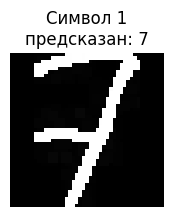

Предсказан как: '7'


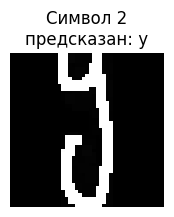

Предсказан как: 'y'


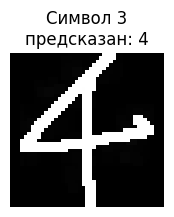

Предсказан как: '4'


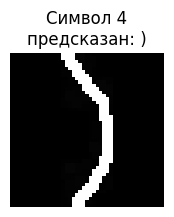

Предсказан как: ')'


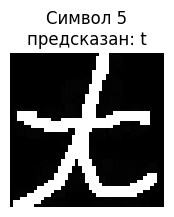

Предсказан как: 't'


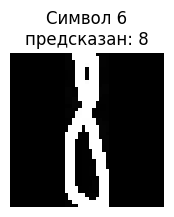

Предсказан как: '8'

Предсказано: '7y4)t8'
Accuracy: 1.00 (6/6 символов)
Модель: knn3


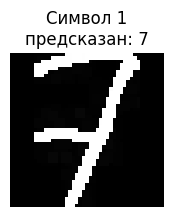

Предсказан как: '7'


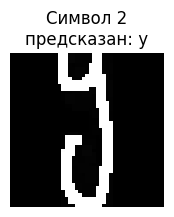

Предсказан как: 'y'


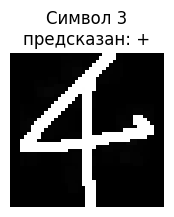

Предсказан как: '+'


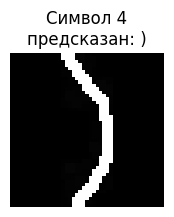

Предсказан как: ')'


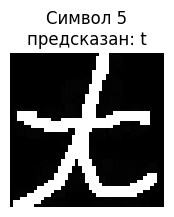

Предсказан как: 't'


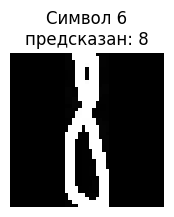

Предсказан как: '8'

 Ошибки распознавания:
Позиция 3: ожидалось '4', получено '+'

Предсказано: '7y+)t8'
Accuracy: 0.83 (5/6 символов)
Модель: knn5


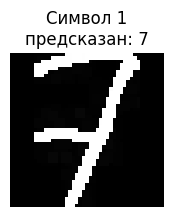

Предсказан как: '7'


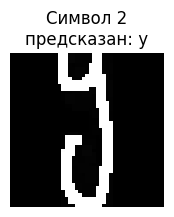

Предсказан как: 'y'


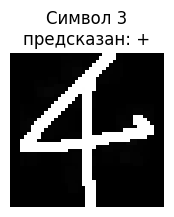

Предсказан как: '+'


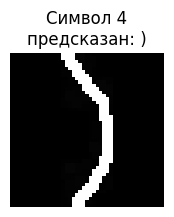

Предсказан как: ')'


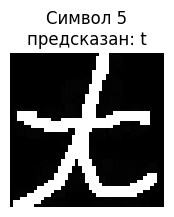

Предсказан как: 't'


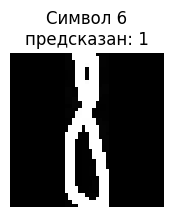

Предсказан как: '1'

 Ошибки распознавания:
Позиция 3: ожидалось '4', получено '+'
Позиция 6: ожидалось '8', получено '1'

Предсказано: '7y+)t1'
Accuracy: 0.67 (4/6 символов)
Модель: knn7


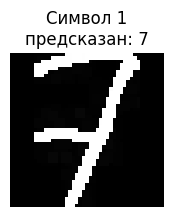

Предсказан как: '7'


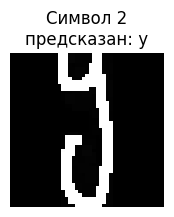

Предсказан как: 'y'


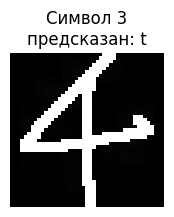

Предсказан как: 't'


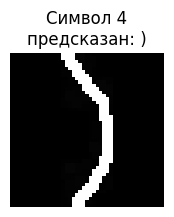

Предсказан как: ')'


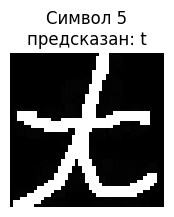

Предсказан как: 't'


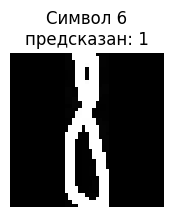

Предсказан как: '1'

 Ошибки распознавания:
Позиция 3: ожидалось '4', получено 't'
Позиция 6: ожидалось '8', получено '1'

Предсказано: '7yt)t1'
Accuracy: 0.67 (4/6 символов)
Сравнение моделей.
knn1    100.0% 6/6 '7y4)t8'
knn3     83.3% 5/6 '7y+)t8'
knn5     66.7% 4/6 '7y+)t1'
knn7     66.7% 4/6 '7yt)t1'


In [56]:
print("6. Распознавание последовательности.")
print(f"Оригинальная последовательность: '{sequence}'")
print(f"Символы: {list(sequence)}")
results = {}
def map_symbol_for_display(symbol):
    if symbol == 'times':
        return '*'
    elif symbol == 'X':
        return 'x'
    return symbol
for model_name, model in models.items():
    print(f"Модель: {model_name}")
    predicted_symbols = []
    for j, (x, symbol_img) in enumerate(resized_symbols):
        predicted_char = predict_symbol(model, symbol_img)
        display_pred = map_symbol_for_display(predicted_char)
        predicted_symbols.append(display_pred)
        plt.figure(figsize=(2, 2))
        plt.imshow(symbol_img, cmap='gray')
        plt.title(f'Символ {j+1}\nпредсказан: {display_pred}')
        plt.axis('off')
        plt.show()
        print(f"Предсказан как: '{display_pred}'")
    predicted_text = ''.join(predicted_symbols)
    original_mapped = ''.join([map_symbol_for_display(s) for s in sequence])
    correct_chars = sum(1 for orig, pred in zip(original_mapped, predicted_symbols) if orig == pred)
    total_chars = len(original_mapped)
    accuracy = correct_chars / total_chars
    if original_mapped != predicted_text:
        print(f"\n Ошибки распознавания:")
        for idx, (orig_char, pred_char) in enumerate(zip(original_mapped, predicted_symbols)):
            if orig_char != pred_char:
                print(f"Позиция {idx+1}: ожидалось '{orig_char}', получено '{pred_char}'")
    print(f"\nПредсказано: '{predicted_text}'")
    print(f"Accuracy: {accuracy:.2f} ({correct_chars}/{total_chars} символов)")
    results[model_name] = {
        'predicted_text': predicted_text,
        'accuracy': accuracy,
        'correct_chars': correct_chars,
        'total_chars': total_chars
    }
print("Сравнение моделей.")
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for model_name, result in sorted_results:
    accuracy_percent = result['accuracy'] * 100
    print(f"{model_name:5} {accuracy_percent:7.1f}% {result['correct_chars']}/{result['total_chars']} '{result['predicted_text']}'")